In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class SphericalClustering(nn.Module):
    def __init__(self, num_covariates, response_dim, num_clusters, distribution = "pkbd", min_weight=0.05, device='cpu'):
        super(SphericalClustering, self).__init__()
        self.num_covariates = num_covariates
        self.response_dim = response_dim
        self.num_clusters = num_clusters
        self.min_weight = torch.tensor(min_weight)
        self.distribution = distribution
        self.device = device

        # Linear layer to map covariates X to K cluster embeddings (Cx(d*K))
        self.A = nn.Linear(num_covariates, response_dim * num_clusters, bias=False)

        # Preallocate Pi as the log of uniform probabilities (no need for .to(device))
        self.pi = torch.log(torch.ones(1, num_clusters) / num_clusters).to(device)  # Uniform Pi in log space
        # Preallocate W matrix (no need for .to(device))
        self.W = torch.zeros(1, num_clusters)  # Placeholder for the W matrix
        self.loglik = -1e10

        # Placeholder for the mask
        self.mask = torch.ones(1, num_clusters, dtype=torch.bool).to(device)
        self.mask_dynamic = torch.ones(1, num_clusters, dtype=torch.bool).to(device)

    @property
    def active_components(self):
        return torch.sum(self.mask).item()
    
    @property
    def df(self):
        return self.num_covariates * self.response_dim * self.active_components
    
    def __repr__(self):
        # Custom string representation
        details = f"Mixture of {self.distribution} Distributional Regressions with {self.active_components} components and {self.num_covariates} covariates.\n"
        details += f"Log-likelihood: {self.loglik}\n"
        details += super().__repr__()  # Include the nn.Module details
        return details

    def forward(self, X):
        # Forward pass to map covariates X to embeddings
        N = X.size(0)
        embeddings = self.A(X)  # Shape: Nx(d*K)
        embeddings = embeddings.view(N, self.num_clusters, self.response_dim)  # Shape: NxKxd
        if (self.num_clusters > 1):
            embeddings = embeddings[:, self.mask.squeeze()]
        # Compute mu (mean direction) by normalizing across the last dimension
        norms = torch.norm(embeddings, dim=-1, keepdim=True)  # Shape: NxKx1
        mu = embeddings / norms  # Normalized embeddings: NxKxd
        
        # Compute rho by link transformation norm/(norm+1)
        rho = norms / (norms + 1)  # Shape: NxKx1
        
        return mu, rho

    def log_likelihood(self, mu, rho, Y, distribution):
        # Calculate log likelihood for each cluster
        N, K, d = mu.shape
        Y = Y.unsqueeze(2)  # Shape: Nx1xd
        cross_prod = torch.bmm(mu, Y).squeeze(-1)  # NxKx1 -> NxK
        rho = rho.squeeze(-1)  # NxKx1 -> NxK

        term1 = torch.log(1 - rho ** 2)  # NxK
        term2 = torch.log(1 + rho ** 2 - 2 * rho * cross_prod)  # NxK

        if distribution == "pkbd":
            loglik = term1 - d*term2/2 # Shape: NxK
        elif distribution == "spcauchy":
            loglik = (d-1)*term1 - (d-1)*term2  # Shape: NxK
        else:
            raise ValueError("Model must be 'pkbd' or 'spcauchy'")
        
        return loglik

    def E_step(self, loglik_detached):
        # Perform E-step with the current model parameters
        # Sum log-likelihood with log Pi (since Pi is in log space)
        loglik_with_pi = loglik_detached + self.pi  # Element-wise sum with log Pi vector
        
        # Apply softmax to get W (posterior probabilities) NxK
        self.W = torch.softmax(loglik_with_pi, dim=1)

        # Update Pi by column means of W
        new_pi = torch.mean(self.W, dim=0, keepdim=True)  # Shape: 1xK

        mask2 = (new_pi >= self.min_weight)
        if torch.any(~mask2):
            removed_clusters = (torch.arange(self.num_clusters)+1).unsqueeze(0).to(self.device)[self.mask][~mask2.squeeze()].tolist()
            updated_mask = self.mask.clone()  # Clone the current mask to avoid in-place memory issues
            updated_mask[self.mask] = mask2  # Only update the active part of the original mask
            self.mask = updated_mask
            self.mask_dynamic = mask2
            loglik_with_pi = loglik_with_pi[:, mask2.squeeze()]
            self.W = torch.softmax(loglik_with_pi, dim=1)
            self.pi = torch.log(torch.mean(self.W, dim=0, keepdim=True))  
            print(f"Clusters {removed_clusters} were removed in this iteration.")
            removed = True
        else:
            self.pi = torch.log(new_pi)
            removed = False

        self.loglik = torch.logsumexp(loglik_with_pi, dim = 1).sum().item()

        return removed

    def M_step(self, X, Y, W):
        # Perform full M-step with recalculation of model parameters and multiple optimization steps
        mu, rho = self(X)
        loglik = self.log_likelihood(mu, rho, Y, self.distribution)
        # Perform backward pass based on the current W
        W_colnorm = W / (torch.sum(W, dim=0, keepdim=True))  # Column normalize W
        weighted_loglik = loglik * W_colnorm  # NxK element-wise multiplication
        cluster_loglik = torch.sum(weighted_loglik, dim=0)  # 1xK
        loss = -torch.mean(cluster_loglik)  # Minimize negative log likelihood

        return loss
    
    def preproc(self, X, Y, N, K, optimizer):
        W = torch.zeros(N, K)
        W.fill_(0.1/(K-1))
        W[:,0] = 0.9 
        perm = torch.stack([torch.randperm(K) for _ in range(N)])
        self.W = torch.gather(W, 1, perm).to(self.device)
        for _ in range(20):
            optimizer.zero_grad()  # Reset gradients
            loss = self.M_step(X, Y, self.W)
            loss.backward()
            optimizer.step()
    
    def fit(self, X, Y, num_epochs=100, num_inner_steps=10, lr = 1e-3, tol = 1e-4, plot = True):
        # Fit the model using EM algorithm
        X = X.to(self.device)
        Y = Y.to(self.device)
        optimizer = optim.AdamW(self.parameters(), lr=lr)

        models_loglik_old = -1e10

        Loglikelihoods = []

        self.train()
        self.preproc(X, Y, X.size(0), self.num_clusters, optimizer)
        for epoch in range(num_epochs):
            # E-step
            optimizer.zero_grad()
            mu, rho = self(X)
            loglik = self.log_likelihood(mu, rho, Y, self.distribution)
            loglik_detached = loglik.detach()  # Detach the log-likelihood before the E-step
            rem = self.E_step(loglik_detached)
            if rem:
                loglik = loglik[:, self.mask_dynamic.squeeze()]
            Loglikelihoods.append(self.loglik)

            if torch.abs(self.loglik - models_loglik_old) < tol*100:
                break
            models_loglik_old = self.loglik

            # M-step
            W_colnorm = self.W / torch.sum(self.W, dim=0, keepdim=True)  # Column normalize W
            weighted_loglik = loglik * W_colnorm  # NxK element-wise multiplication
            cluster_loglik = torch.sum(weighted_loglik, dim=0)  # 1xK
            loss = -torch.mean(cluster_loglik)  # Minimize negative log likelihood
            loss.backward()
            optimizer.step()

            # Perform n-1 more M-steps with re-evaluations
            old_loss = loss.item()
            for step in range(num_inner_steps-1):
                optimizer.zero_grad()  # Reset gradients
                loss = self.M_step(X, Y, self.W)
                if abs(loss.item() - old_loss) < tol:
                    print(f'   Inner_step {step + 2}/{num_inner_steps}, Loss: {loss.item()}')
                    break
                loss.backward()
                optimizer.step()  # Update model parameters
                old_loss = loss.item()
            loss = loss.item()

            if (epoch + 1) % 1 == 0:
                print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss}, Log-likelihood: {self.loglik}')
        
        if plot:
            # plot the log-likelihoods over the epochs and return them
            plt.plot(range(epoch+1)[3:], Loglikelihoods[3:])
            plt.xlabel('Epochs')
            plt.ylabel('Log-likelihood')
            plt.title('Log-likelihood over epochs')
        return Loglikelihoods
    
    def get_final_W(self, dataloader):
        """
        Compute the final W matrix (posterior probabilities) for the entire dataset.

        Args:
            dataloader (DataLoader): DataLoader for the dataset (must not shuffle data).

        Returns:
            torch.Tensor: The final W matrix of shape (N, K).
        """
        self.eval()  # Set the model to evaluation mode
        W_list = []
        ll = 0

        with torch.no_grad():
            for batch in dataloader:
                X_batch, Y_batch = batch
                X_batch = X_batch.to(self.device)
                Y_batch = Y_batch.to(self.device)

                # Forward pass
                mu, rho = self(X_batch)
                loglik = self.log_likelihood(mu, rho, Y_batch, self.distribution)
                
                # Compute loglikelihood with current Pi (in log space)
                loglik_with_pi = loglik + self.pi  # self.pi is in log space

                # Compute W for this batch
                W_batch = torch.softmax(loglik_with_pi, dim=1)
                # Final log-likelihood
                ll += torch.logsumexp(loglik_with_pi, dim = 1).sum()
                # Append W_batch to W_list
                W_list.append(W_batch)

        # Concatenate W_list to get full W matrix
        self.loglik = ll
        self.W = torch.cat(W_list, dim=0)  # Shape: (N, K)
        self.pi = torch.log(torch.mean(self.W, dim=0, keepdim=True))  # Update Pi
        return None

    def preproc_dataloader(self, dataloader, K, optimizer):
        N = len(dataloader.dataset)
        W = torch.zeros(N, K)
        W.fill_(0.1/(K-1))
        W[:,0] = 0.9 
        perm = torch.stack([torch.randperm(K) for _ in range(N)])
        self.W = torch.gather(W, 1, perm)
        for _ in range(20):
            optimizer.zero_grad()  # Reset gradients
            for batch in dataloader:
                X, Y, idx = batch
                X = X.to(self.device)
                Y = Y.to(self.device)
                W_batch = self.W[idx].to(self.device)
                loss = self.M_step(X, Y, W_batch)
                loss.backward()
            optimizer.step()

    def fit_dataloader(self, dataloader, num_epochs=100, num_inner_steps=10, lr = 1e-3, tol = 1e-4, plot = True):
        # Fit the model using EM algorithm
        optimizer = optim.AdamW(self.parameters(), lr=lr)
        models_loglik_old = -1e10
        defined_batch_size = dataloader.batch_size
        Loglikelihoods = []

        self.train()
        self.preproc_dataloader(dataloader, self.num_clusters, optimizer)
        for epoch in range(num_epochs):
            epoch_loglik = 0
            epoch_loss = 0
            total_N = 0
            W_list = []

            # E-step
            for batch in dataloader:
                X, Y, idx = batch
                X = X.to(self.device)
                Y = Y.to(self.device)

                with torch.no_grad():
                    mu, rho = self(X)
                    loglik = self.log_likelihood(mu, rho, Y, self.distribution)
                    loglik_with_pi = loglik + self.pi  # Element-wise sum with log Pi vector        
                    W_batch = torch.softmax(loglik_with_pi, dim=1)
                    W_list.append(W_batch)
                    batch_loglik = torch.logsumexp(loglik_with_pi, dim = 1).sum()
                    epoch_loglik += batch_loglik.item()

            # Update Pi by column means of W
            self.W = torch.cat(W_list, dim=0)
            new_pi = torch.mean(self.W, dim=0, keepdim=True)  # Shape: 1xK

            mask2 = (new_pi >= self.min_weight)
            if torch.any(~mask2):
                removed_clusters = (torch.arange(self.num_clusters)+1).unsqueeze(0).to(self.device)[self.mask][~mask2.squeeze()].tolist()
                updated_mask = self.mask.clone()  # Clone the current mask to avoid in-place memory issues
                updated_mask[self.mask] = mask2  # Only update the active part of the original mask
                self.mask = updated_mask
                new_pi = new_pi[:, mask2.squeeze()]
                self.pi = torch.log(new_pi / new_pi.sum(dim=1, keepdim=True))
                print(f"Clusters {removed_clusters} were removed in this iteration.")
            else:
                self.pi = torch.log(new_pi)

            self.loglik = epoch_loglik
            Loglikelihoods.append(self.loglik)
            if abs(self.loglik - models_loglik_old) < tol*100:
                break
            models_loglik_old = self.loglik 

            # M-step
            W_colnorm = self.W / torch.sum(self.W, dim=0, keepdim=True)  # Column normalize W
            for step in range(num_inner_steps):
                old_loss = 1e10
                step_loss = 0
                optimizer.zero_grad()
                for batch in dataloader:
                    X, Y, idx = batch
                    X = X.to(self.device)
                    Y = Y.to(self.device)
                    W_batch = W_colnorm[idx].to(self.device)
                    actual_batch_size = X.size(0)
                    loss_weight = actual_batch_size / defined_batch_size
                    loss = self.M_step(X, Y, W_batch)*loss_weight
                    step_loss += loss.item()
                    loss.backward()
                optimizer.step()
                if abs(step_loss - old_loss) < tol:
                    print(f'   Inner_step {step + 1}/{num_inner_steps}, Loss: {step_loss}')
                    break
                old_loss = step_loss
            epoch_loss = step_loss    
            if (epoch + 1) % 1 == 0:
                print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss}, Log-likelihood: {self.loglik}')    


        if plot:
            # plot the log-likelihoods over the epochs and return them
            plt.plot(range(epoch+1)[3:], Loglikelihoods[3:])
            plt.xlabel('Epochs')
            plt.ylabel('Log-likelihood')
            plt.title('Log-likelihood over epochs')
        return Loglikelihoods
    
    def predict(self, X):
        # Predict the cluster assignments
        self.eval()
        with torch.inference_mode():
            X = X.to(self.device)
            return self(X)

    def predict_and_cluster(self, X, Y):
        # Predict the cluster assignments and return the cluster assignments
        self.eval()
        with torch.inference_mode():
            X = X.to(self.device)
            Y = Y.to(self.device)
            mu, rho = self(X)
            loglik = self.log_likelihood(mu, rho, Y, self.distribution)
            loglik_with_pi = loglik + self.pi  # Element-wise sum with log Pi vector
            posterior = torch.softmax(loglik_with_pi, dim=1)
            return posterior, mu, rho
                  
       

In [278]:
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = "cuda"
N, C, d, K = 20000, 2, 1024, 8  # Example dimensions
X = torch.randn(N, C)  # Covariates NxC
Y = torch.randn(N, d)  # Response Nxd
Y = Y / torch.norm(Y, dim=1, keepdim=True)  # Normalize Y

model = SphericalClustering(num_covariates=C, response_dim=d, num_clusters=K, device=device)
model.to(device)  # Move the entire model to the device

Mixture of pkbd Distributional Regressions with 8 components and 2 covariates.
Log-likelihood: -10000000000.0
SphericalClustering(
  (A): Linear(in_features=2, out_features=8192, bias=False)
)

In [4]:
#X = torch.tensor(np.load('data/pkbd_X_fac.npy')).float()
#Y = torch.tensor(np.load('data/pkbd_Y.npy')).float()
X = torch.tensor(np.load('data/Abstracts256_X.npy')).float()
#X = torch.ones(X.shape[0], 1)
Y = torch.tensor(np.load('data/Abstracts256_Y.npy')).float()
model = SphericalClustering(num_covariates=X.shape[1], response_dim=Y.shape[1], num_clusters=8, device="cpu", min_weight=0.05)
X.shape, Y.shape

(torch.Size([129, 2]), torch.Size([129, 256]))

Epoch 1/200, Loss: -80.8254623413086, Log-likelihood: 6131.59765625
Epoch 2/200, Loss: -127.95555114746094, Log-likelihood: 11351.5810546875
Clusters [1] were removed in this iteration.
Epoch 3/200, Loss: -121.23213958740234, Log-likelihood: 12356.130859375
Epoch 4/200, Loss: -123.58891296386719, Log-likelihood: 13616.244140625
Epoch 5/200, Loss: -125.27057647705078, Log-likelihood: 14140.0693359375
Epoch 6/200, Loss: -129.11114501953125, Log-likelihood: 14418.265625
Epoch 7/200, Loss: -135.4825439453125, Log-likelihood: 14656.5517578125
Epoch 8/200, Loss: -150.28884887695312, Log-likelihood: 15420.0390625
Epoch 9/200, Loss: -178.4807891845703, Log-likelihood: 15935.4853515625
Clusters [4] were removed in this iteration.
Epoch 10/200, Loss: -146.2781219482422, Log-likelihood: 14651.66015625
Epoch 11/200, Loss: -152.2270050048828, Log-likelihood: 14919.908203125
Epoch 12/200, Loss: -156.5877685546875, Log-likelihood: 15252.470703125
Epoch 13/200, Loss: -163.1600799560547, Log-likelihood

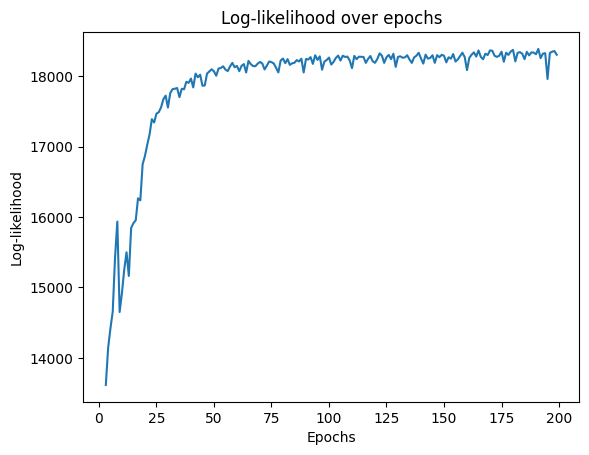

In [286]:
l= model.fit(X, Y, num_epochs=200, num_inner_steps=20, lr=0.1, tol=1e-4)

In [287]:
print(model)
print(torch.exp(model.pi))
mu, rho = model.predict(X[2:3,:])
rho

Mixture of pkbd Distributional Regressions with 6 components and 2 covariates.
Log-likelihood: 18305.71484375
SphericalClustering(
  (A): Linear(in_features=2, out_features=2048, bias=False)
)
tensor([[0.0620, 0.1122, 0.0893, 0.5814, 0.0853, 0.0698]])


tensor([[[0.9843],
         [0.9704],
         [0.9842],
         [0.6376],
         [0.9968],
         [0.9650]]])

In [75]:
torch.exp(model.pi)

tensor([[0.4006, 0.2043, 0.3951]])

In [10]:
from torch.utils.data import DataLoader, Dataset

class IndexedDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], idx  # Return the index


dataset = IndexedDataset(X, Y)
dataloader = DataLoader(dataset, batch_size=100, shuffle=False)

In [9]:
model.fit_dataloader(dataloader, num_epochs=200, num_inner_steps=10, lr=1e-1)

Epoch 1/200, Loss: 61263.288719177246, Log-likelihood: -5894153.748046875
Epoch 2/200, Loss: 62762.79364013672, Log-likelihood: -6524454.03125
Epoch 3/200, Loss: 63045.028717041016, Log-likelihood: -6539751.767578125
Epoch 4/200, Loss: 63130.889556884766, Log-likelihood: -6543352.759765625
Epoch 5/200, Loss: 63192.55270385742, Log-likelihood: -6550698.8828125
Epoch 6/200, Loss: 63252.24963378906, Log-likelihood: -6551140.306640625
Epoch 7/200, Loss: 63262.919982910156, Log-likelihood: -6551410.26171875
Epoch 8/200, Loss: 63227.69934082031, Log-likelihood: -6551764.92578125
Epoch 9/200, Loss: 63286.20300292969, Log-likelihood: -6550014.697265625
Epoch 10/200, Loss: 63233.219665527344, Log-likelihood: -6550895.05078125
Epoch 11/200, Loss: 63222.3274230957, Log-likelihood: -6551404.6328125
Epoch 12/200, Loss: 63290.01306152344, Log-likelihood: -6550825.9765625
Epoch 13/200, Loss: 63252.67108154297, Log-likelihood: -6549172.65234375
Epoch 14/200, Loss: 63281.55172729492, Log-likelihood: -6

KeyboardInterrupt: 

Epoch 1/200, Loss: 285.3896484375, Log-likelihood: -5908214.0
Epoch 2/200, Loss: 272.39190673828125, Log-likelihood: -5720939.0
Epoch 3/200, Loss: 249.84552001953125, Log-likelihood: -5444909.0
Epoch 4/200, Loss: 198.98013305664062, Log-likelihood: -4926158.5
Epoch 5/200, Loss: 92.76785278320312, Log-likelihood: -3687273.5
Epoch 6/200, Loss: 22.7945556640625, Log-likelihood: -1163354.625
Clusters [4, 5] were removed in this iteration.
Epoch 7/200, Loss: 5.877457618713379, Log-likelihood: -373258.6875
Epoch 8/200, Loss: 1.6399049758911133, Log-likelihood: -117503.4765625
Clusters [2, 7] were removed in this iteration.
Epoch 9/200, Loss: 0.35242199897766113, Log-likelihood: -41888.2421875
Epoch 10/200, Loss: -0.4440304636955261, Log-likelihood: -14433.525390625
Epoch 11/200, Loss: -0.7784687280654907, Log-likelihood: -2658.5595703125
Clusters [3] were removed in this iteration.
Epoch 12/200, Loss: -0.3663420081138611, Log-likelihood: -761.77490234375
Epoch 13/200, Loss: -0.47928696870803

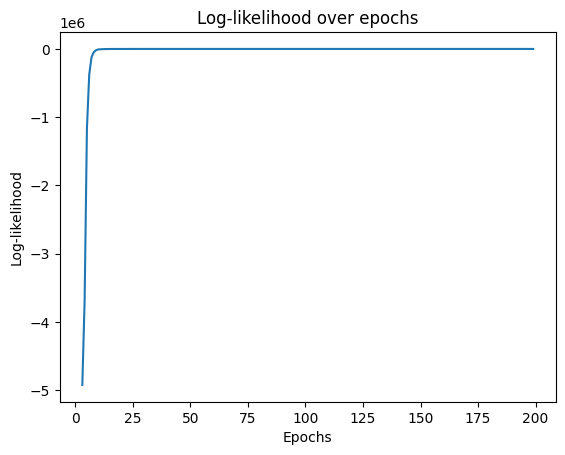

In [4]:
loglikkkks = model.fit(X, Y, num_epochs=200, num_inner_steps=10, lr=1e-2)

In [269]:
N = 250
K = 4

        

W = torch.zeros(N, K)
W.fill_(0.1/(K-1))
W[:,0] = 0.9 
perm = torch.stack([torch.randperm(K) for _ in range(N)])
torch.gather(W, 1, perm)

tensor([[0.0333, 0.9000, 0.0333, 0.0333],
        [0.0333, 0.9000, 0.0333, 0.0333],
        [0.0333, 0.9000, 0.0333, 0.0333],
        [0.0333, 0.0333, 0.9000, 0.0333],
        [0.0333, 0.0333, 0.9000, 0.0333],
        [0.9000, 0.0333, 0.0333, 0.0333],
        [0.0333, 0.9000, 0.0333, 0.0333],
        [0.0333, 0.0333, 0.9000, 0.0333],
        [0.9000, 0.0333, 0.0333, 0.0333],
        [0.9000, 0.0333, 0.0333, 0.0333],
        [0.0333, 0.0333, 0.9000, 0.0333],
        [0.9000, 0.0333, 0.0333, 0.0333],
        [0.0333, 0.9000, 0.0333, 0.0333],
        [0.0333, 0.9000, 0.0333, 0.0333],
        [0.9000, 0.0333, 0.0333, 0.0333],
        [0.0333, 0.9000, 0.0333, 0.0333],
        [0.0333, 0.0333, 0.9000, 0.0333],
        [0.0333, 0.9000, 0.0333, 0.0333],
        [0.0333, 0.0333, 0.9000, 0.0333],
        [0.0333, 0.0333, 0.0333, 0.9000],
        [0.9000, 0.0333, 0.0333, 0.0333],
        [0.0333, 0.0333, 0.9000, 0.0333],
        [0.0333, 0.0333, 0.0333, 0.9000],
        [0.0333, 0.9000, 0.0333, 0